### Chronic Wasting Disease (CWD) - Exploratory Data Analysis/Wild and Captive Disease Distribution
#### Author: Maria Julia Judson
#### This notebook uses USGS data to analyze the distribution of CWD presence across U.S. states and prepares a dataset for visualization in Power BI.

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
wild_df = pd.read_csv("20250408_CWD_Wild.csv")
captive_df = pd.read_csv("20250408_CWD_Captive.csv")

In [3]:
wild_df.head()

,State,County
0,Alabama,Colbert
1,Alabama,Lauderdale
2,Arkansas,Baxter
3,Arkansas,Benton
4,Arkansas,Boone


In [30]:
num_wild_cwd_states = len(wild_summary)
total_wild_cwd_counties = wild_summary['wild_CWD_affected_counties'].sum()

print(f"Number of states affected by wild CWD: {num_wild_cwd_states}")
print(f"Total number of counties with wild CWD: {total_wild_cwd_counties}")

Number of states affected by wild CWD: 36
Total number of counties with wild CWD: 593


Wild/free-range CWD presence dataset, showcasing 36 positive states with 593 positive counties.

In [4]:
captive_df.head()

,State,County,Count
0,Colorado,Delta,2
1,Colorado,Eagle,2
2,Colorado,El Paso,1
3,Colorado,Fremont,1
4,Colorado,Garfield,1


In [31]:
num_captive_cwd_states = len(captive_summary)
total_captive_cwd_counties = captive_summary['captive_CWD_affected_counties'].sum()

print(f"Number of states affected by captive CWD: {num_captive_cwd_states}")
print(f"Total number of counties with captive CWD: {total_captive_cwd_counties}")

Number of states affected by captive CWD: 22
Total number of counties with captive CWD: 166


Captive CWD presence dataset, showcasing 22 positive states with 166 positive counties.

In [5]:
wild_df.columns

Index(['State', 'County'], dtype='object')

In [6]:
captive_df.columns

Index(['State', 'County', 'Count'], dtype='object')

In [7]:
wild_df.columns = wild_df.columns.str.lower().str.strip()
captive_df.columns = captive_df.columns.str.lower().str.strip()

In [32]:
wild_summary = wild_df["state"].value_counts().reset_index()
wild_summary.columns = ["state", "wild_CWD_affected_counties"]

wild_summary_sorted = wild_summary.sort_values(
    by="wild_CWD_affected_counties",
    ascending=False
)
display(wild_summary_sorted.head(10))

,state,wild_CWD_affected_counties
0,Nebraska,68
1,Kansas,64
2,Wisconsin,49
3,Missouri,41
4,Montana,37
5,Iowa,29
6,Colorado,27
7,Illinois,25
8,Arkansas,24
9,South Dakota,22


Number of counties per state affected by wild/free-ranging CWD, shown in descending order.

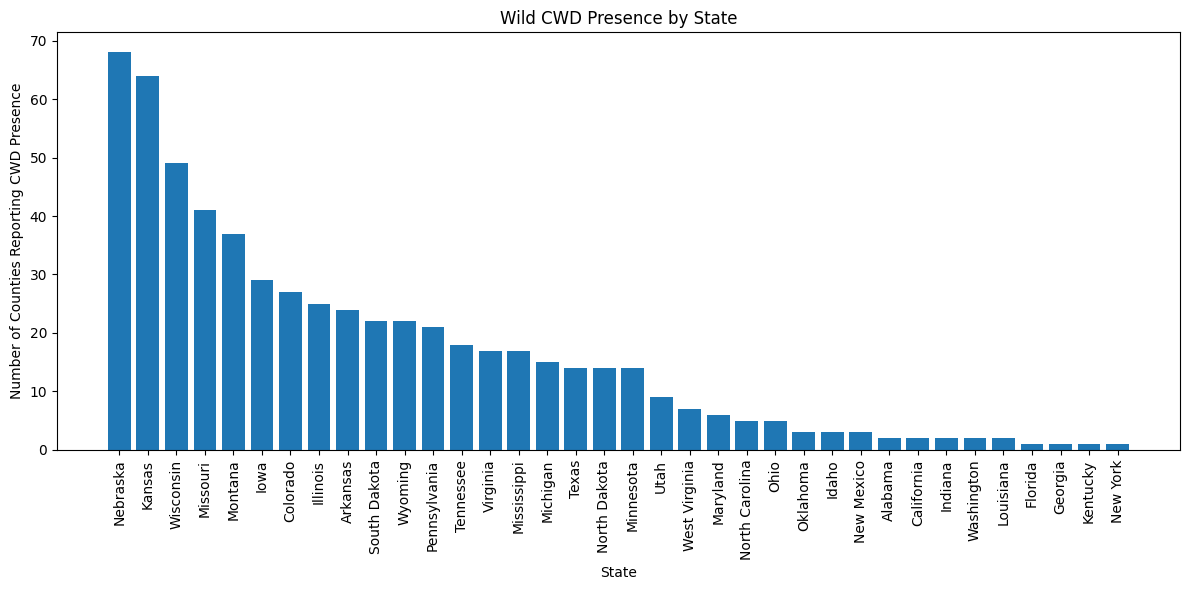

In [35]:
# Sort wild data
wild_summary_sorted = wild_summary.sort_values(
    by="wild_CWD_affected_counties",
    ascending=False
)

plt.figure(figsize=(12, 6))

plt.bar(
    wild_summary_sorted["state"],
    wild_summary_sorted["wild_CWD_affected_counties"]
)

plt.title("Wild CWD Presence by State")
plt.xlabel("State")
plt.ylabel("Number of Counties Reporting CWD Presence")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

The graph displays the number of counties per state with confirmed wild cervid CWD presence, arranged in decreasing order. Among the 36 states exhibited, Nebraska has the highest number of affected counties (68), followed by Kansas and Wisconsin. In contrast, states such as New York report the lowest presence, with only one affected county.

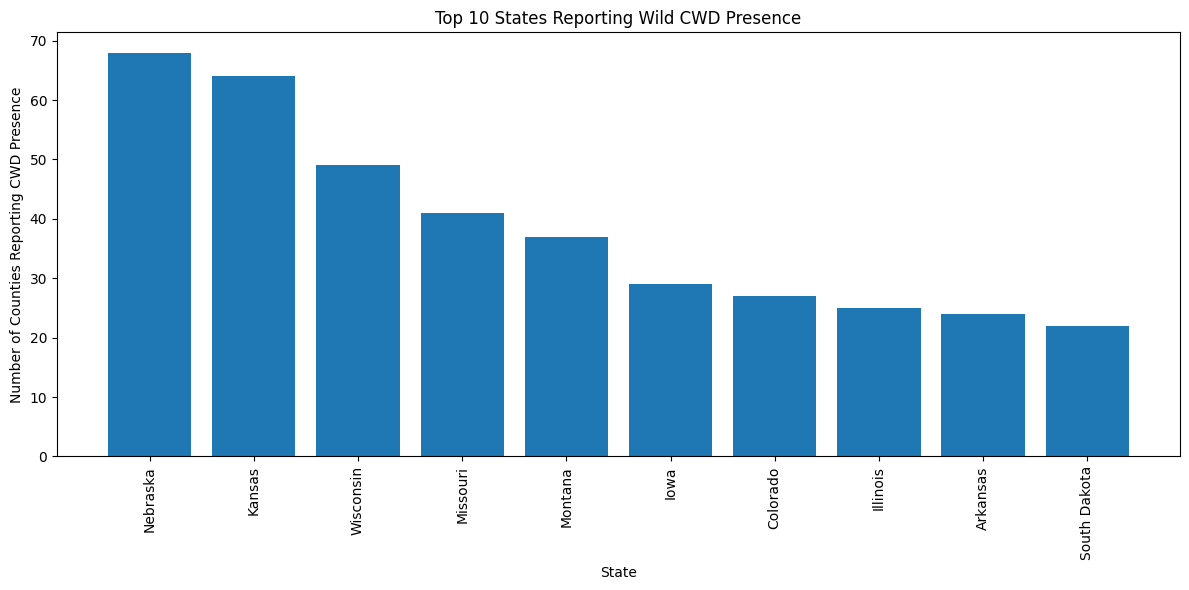

In [36]:
# Sort wild data and get the top 10
wild_summary_sorted_top10 = wild_summary.sort_values(
    by="wild_CWD_affected_counties",
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    wild_summary_sorted_top10["state"],
    wild_summary_sorted_top10["wild_CWD_affected_counties"]
)

plt.title("Top 10 States Reporting Wild CWD Presence")
plt.xlabel("State")
plt.ylabel("Number of Counties Reporting CWD Presence")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Top 10 US States reporting wild CWD presence, in decreasing order.

In [11]:
captive_summary = captive_df["state"].value_counts().reset_index()
captive_summary.columns = ["state", "captive_CWD_affected_counties"]

captive_summary.head()

,state,captive_CWD_affected_counties
0,Wisconsin,32
1,Texas,23
2,Colorado,17
3,Pennsylvania,17
4,Minnesota,12


Number of counties per state affected by captive CWD, shown in descending order.

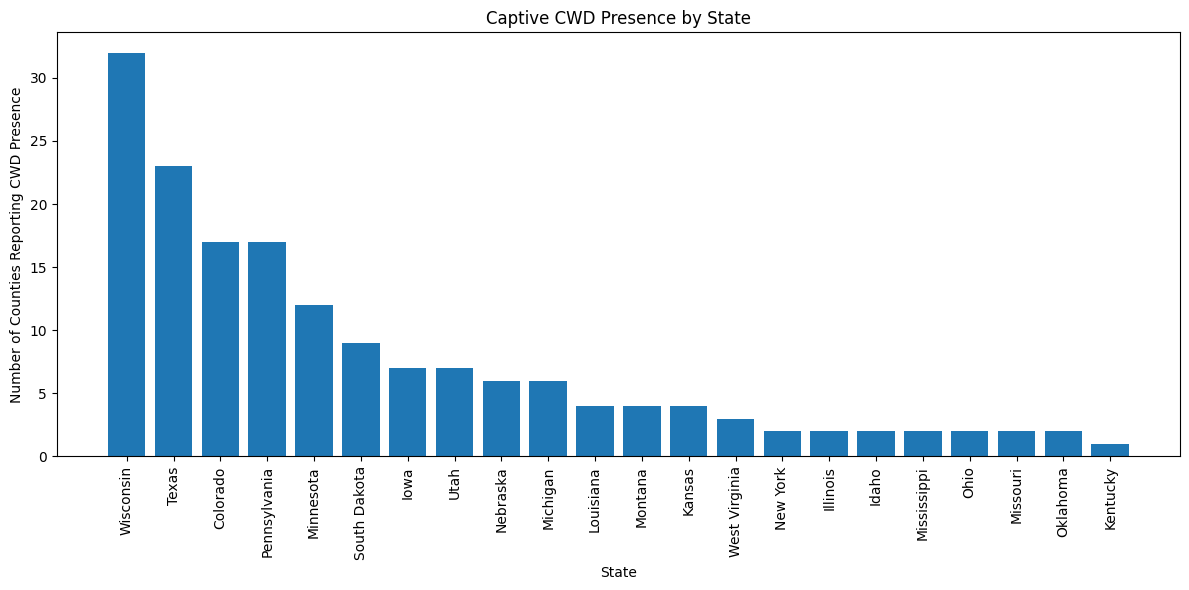

In [20]:
# Sort captive data
captive_summary_sorted = captive_summary.sort_values(
    by="captive_CWD_affected_counties",
    ascending=False
)

plt.figure(figsize=(12, 6))

plt.bar(
    captive_summary_sorted["state"],
    captive_summary_sorted["captive_CWD_affected_counties"]
)

plt.title("Captive CWD Presence by State")
plt.xlabel("State")
plt.ylabel("Number of Counties Reporting CWD Presence")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

The graph displays the number of counties per state with confirmed captive cervid CWD presence, arranged in decreasing order. Among the 22 states exhibited, Wisconsin has the highest number of affected counties, followed by Texas and Colorado. In contrast, Kentucky reports the lowest presence.

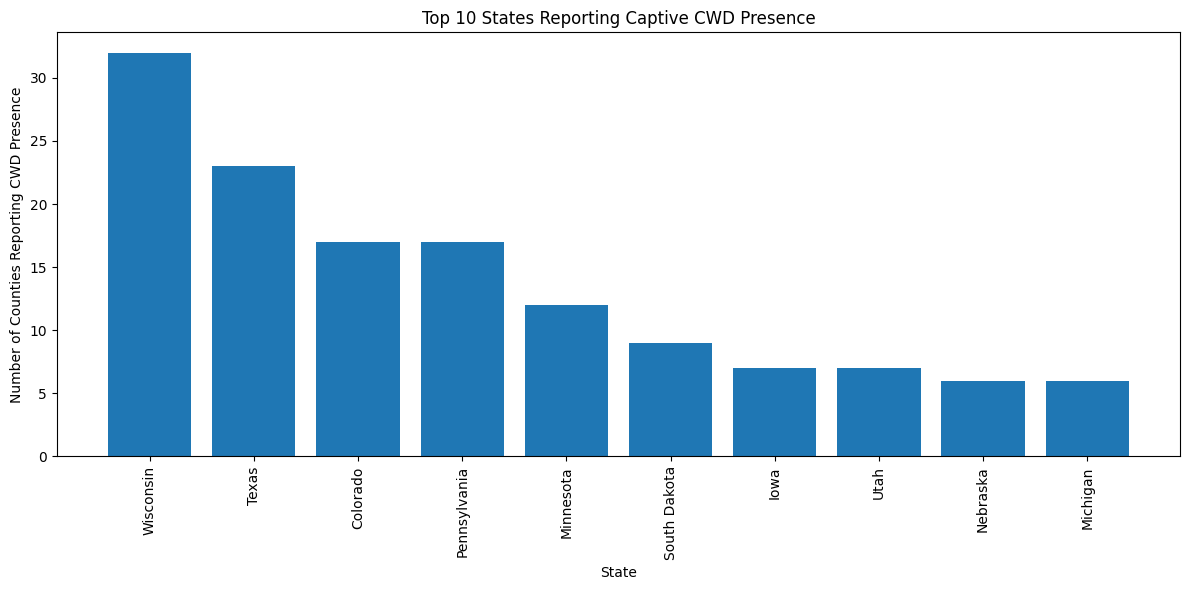

In [37]:
# Sort captive data and get the top 10
captive_summary_sorted_top10 = captive_summary.sort_values(
    by="captive_CWD_affected_counties",
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    captive_summary_sorted_top10["state"],
    captive_summary_sorted_top10["captive_CWD_affected_counties"]
)

plt.title("Top 10 States Reporting Captive CWD Presence")
plt.xlabel("State")
plt.ylabel("Number of Counties Reporting CWD Presence")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Top 10 US States reporting captive CWD presence, in decreasing order.

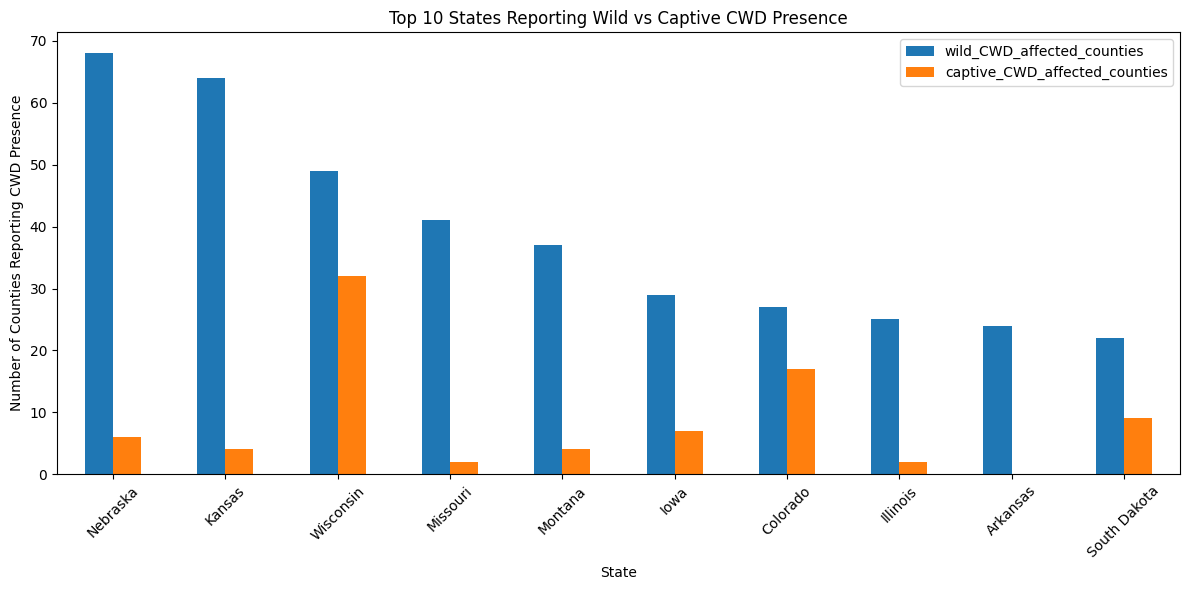

In [24]:
combined = pd.merge(
    wild_summary,
    captive_summary,
    on="state",
    how="outer"
).fillna(0)

combined_sorted = combined.sort_values(
    by="wild_CWD_affected_counties",
    ascending=False
).head(10)

combined_sorted.set_index("state")[[
    "wild_CWD_affected_counties",
    "captive_CWD_affected_counties"
]].plot(kind="bar", figsize=(12,6))

plt.title("Top 10 States Reporting Wild vs Captive CWD Presence")
plt.xlabel("State")
plt.ylabel("Number of Counties Reporting CWD Presence")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In this graph, it can be seen that CWD distribution is consistently more widespread in wild cervid populations across all top reporting states. However, states such as Wisconsin and Colorado exhibit a relatively higher burden in captive populations, suggesting potential epidemiological links or differences in surveillance intensity. The dominance of wild cases highlights the challenge of controlling disease spread in free-ranging populations.